In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data
churn_df = pd.read_csv('telco_churn_cleaned.csv')

# Verify
print(" Data loaded successfully!")
print(f"Shape: {churn_df.shape}")
print(f"Columns: {churn_df.columns.tolist()[:10]}...")

✅ Data loaded successfully!
Shape: (7043, 23)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity']...


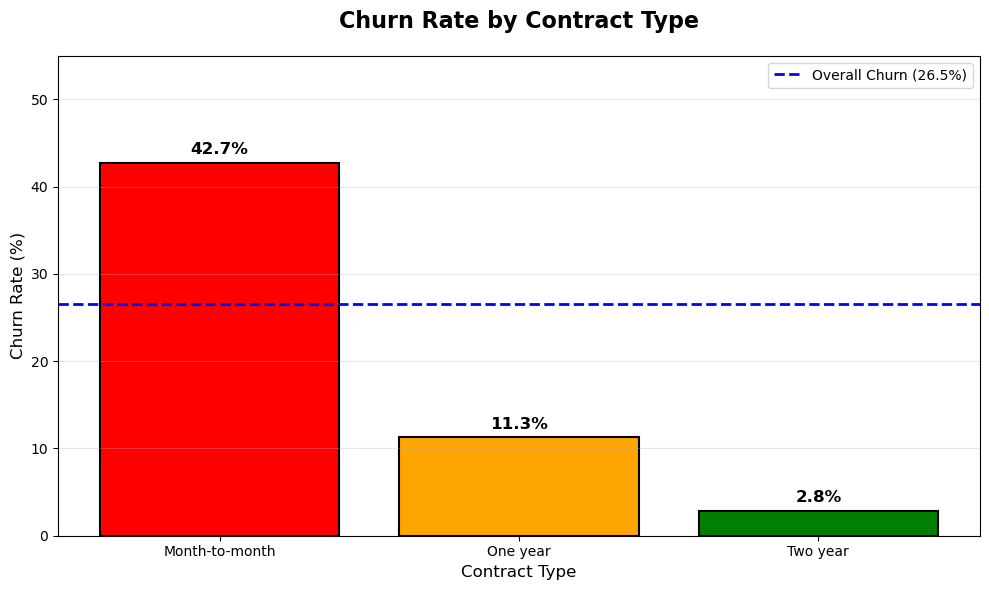

✅ Saved: churn_by_contract.png


<Figure size 640x480 with 0 Axes>

In [2]:
# Calculate data
contract_churn = churn_df.groupby('Contract')['churn_binary'].mean() * 100

# Create figure
plt.figure(figsize=(10, 6))
colors = ['red', 'orange', 'green']
bars = plt.bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Contract Type', fontsize=12)
plt.ylim(0, 55)
plt.axhline(y=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='upper right')

# Add value labels on bars
for bar, val in zip(bars, contract_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Save
plt.savefig('churn_by_contract.png', dpi=300, bbox_inches='tight')
print("Saved: churn_by_contract.png")

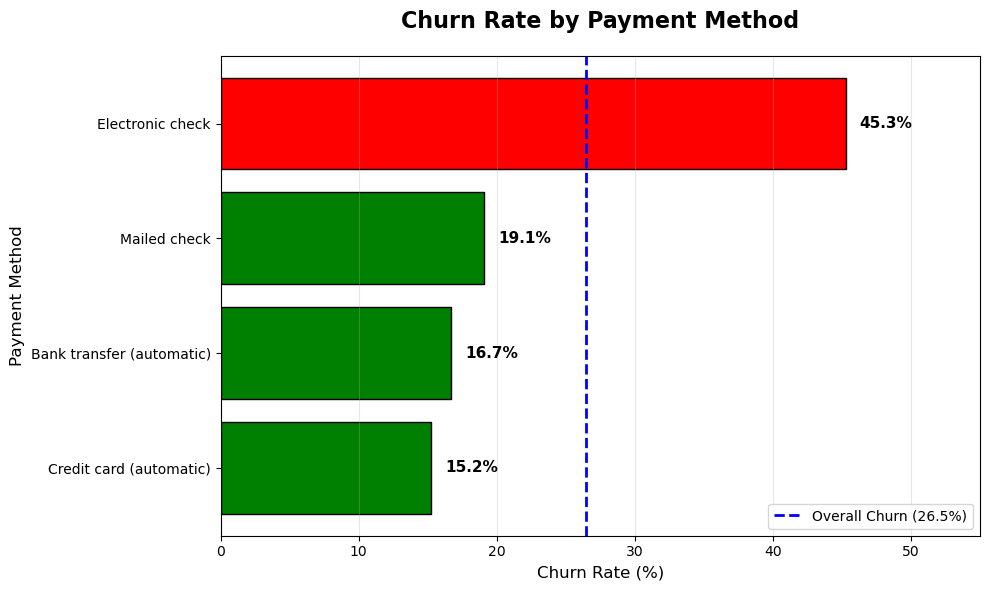

✅ Saved: churn_by_payment.png


<Figure size 640x480 with 0 Axes>

In [3]:
# Calculate data
payment_churn = churn_df.groupby('PaymentMethod')['churn_binary'].mean() * 100
payment_churn = payment_churn.sort_values(ascending=True)

# Create figure
plt.figure(figsize=(10, 6))
colors = ['green' if x < 20 else 'orange' if x < 30 else 'red' for x in payment_churn.values]
bars = plt.barh(payment_churn.index, payment_churn.values, color=colors, edgecolor='black', linewidth=1)

# Customize
plt.title('Churn Rate by Payment Method', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
plt.xlim(0, 55)
plt.axvline(x=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='lower right')

# Add value labels
for bar, val in zip(bars, payment_churn.values):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Save
plt.savefig('churn_by_payment.png', dpi=300, bbox_inches='tight')
print("Saved: churn_by_payment.png")

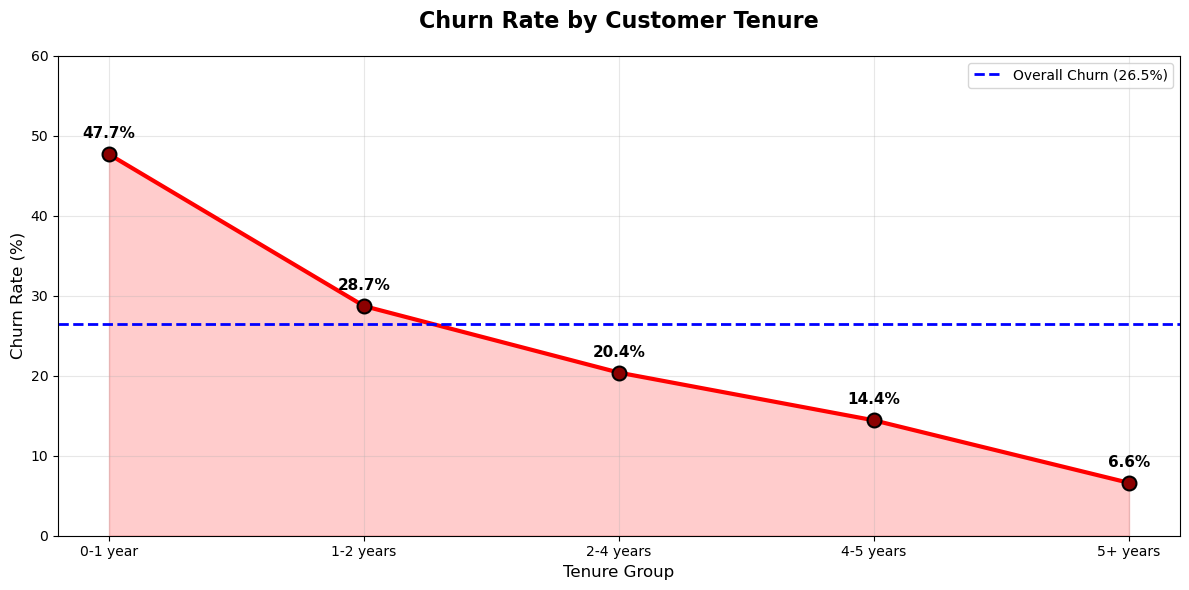

✅ Saved: churn_by_tenure.png


<Figure size 640x480 with 0 Axes>

In [4]:
# Calculate data
tenure_order = ['0-1 year', '1-2 years', '2-4 years', '4-5 years', '5+ years']
tenure_churn = churn_df.groupby('tenure_group')['churn_binary'].mean() * 100
tenure_churn = tenure_churn.reindex(tenure_order)

# Create figure
plt.figure(figsize=(12, 6))
plt.plot(tenure_churn.index, tenure_churn.values, marker='o', linewidth=3, markersize=10, 
         color='red', markerfacecolor='darkred', markeredgecolor='black', markeredgewidth=1.5)
plt.fill_between(tenure_churn.index, tenure_churn.values, alpha=0.2, color='red')

# Customize
plt.title('Churn Rate by Customer Tenure', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Tenure Group', fontsize=12)
plt.ylim(0, 60)
plt.axhline(y=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='upper right')

# Add value labels
for i, val in enumerate(tenure_churn.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save
plt.savefig('churn_by_tenure.png', dpi=300, bbox_inches='tight')
print("Saved: churn_by_tenure.png")

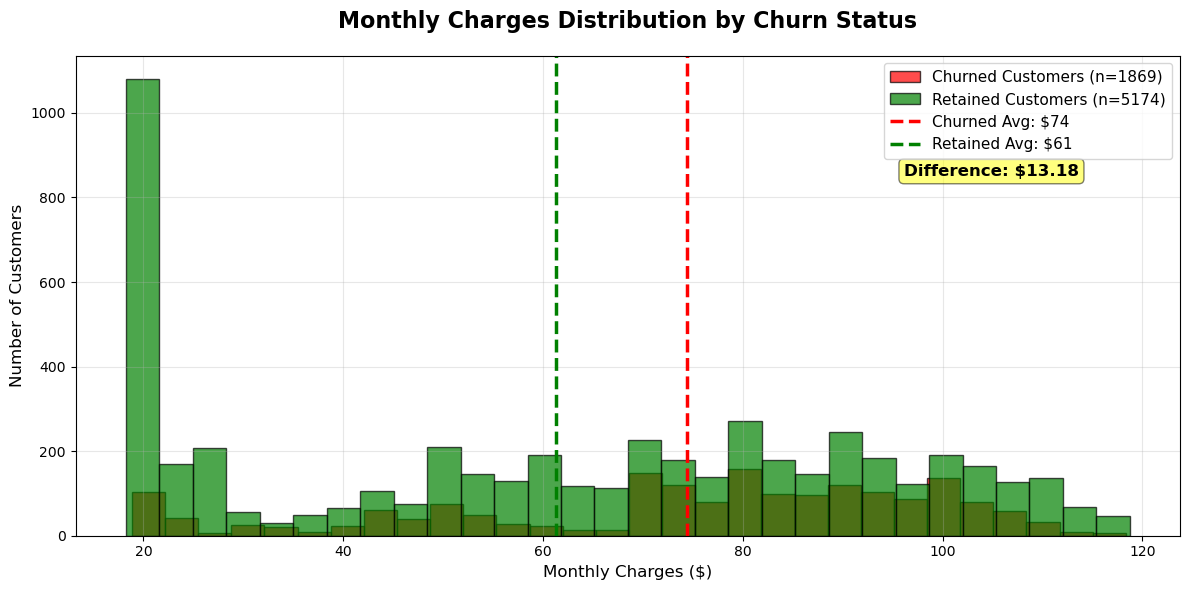

✅ Saved: monthly_charges_distribution.png


<Figure size 640x480 with 0 Axes>

In [7]:
# Separate data
churned = churn_df[churn_df['Churn'] == 'Yes']['MonthlyCharges']
retained = churn_df[churn_df['Churn'] == 'No']['MonthlyCharges']

# Create figure
plt.figure(figsize=(12, 6))
plt.hist(churned, bins=30, alpha=0.7, label=f'Churned Customers (n={len(churned)})', 
         color='red', edgecolor='black', linewidth=1)
plt.hist(retained, bins=30, alpha=0.7, label=f'Retained Customers (n={len(retained)})', 
         color='green', edgecolor='black', linewidth=1)

# Add vertical lines for averages
avg_churned = churned.mean()
avg_retained = retained.mean()
plt.axvline(x=avg_churned, color='red', linestyle='--', linewidth=2.5, label=f'Churned Avg: ${avg_churned:.0f}')
plt.axvline(x=avg_retained, color='green', linestyle='--', linewidth=2.5, label=f'Retained Avg: ${avg_retained:.0f}')

# Customize
plt.title('Monthly Charges Distribution by Churn Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)

# Add text annotation for difference
difference = avg_churned - avg_retained
plt.text(0.75, 0.75, f'Difference: ${difference:.2f}', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

# Save
plt.savefig('monthly_charges_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: monthly_charges_distribution.png")

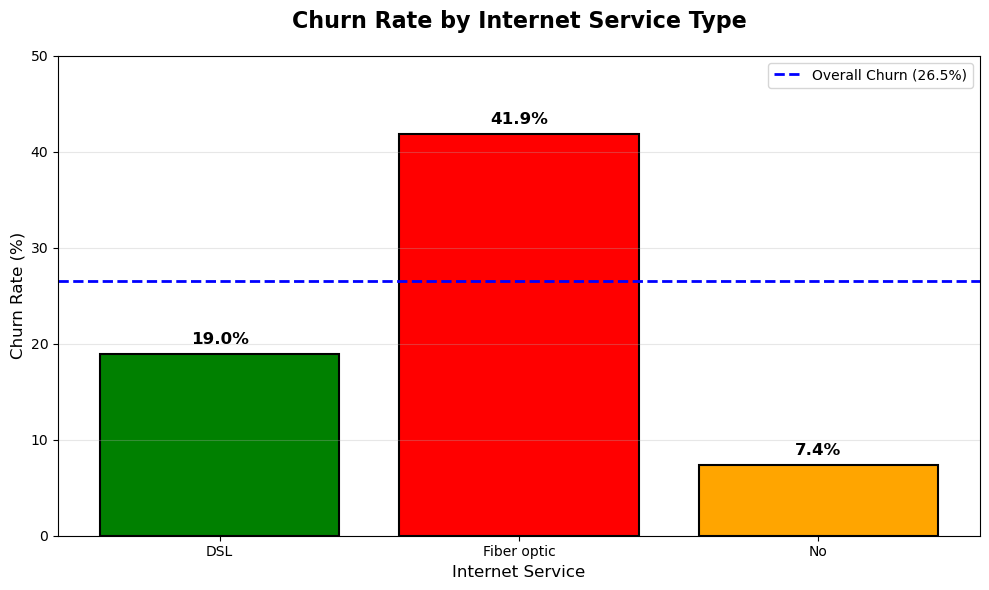

✅ Saved: churn_by_internet.png


<Figure size 640x480 with 0 Axes>

In [8]:
# Calculate data
internet_churn = churn_df.groupby('InternetService')['churn_binary'].mean() * 100

# Create figure
plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'orange']
bars = plt.bar(internet_churn.index, internet_churn.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize
plt.title('Churn Rate by Internet Service Type', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Internet Service', fontsize=12)
plt.ylim(0, 50)
plt.axhline(y=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='upper right')

# Add value labels
for bar, val in zip(bars, internet_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Save
plt.savefig('churn_by_internet.png', dpi=300, bbox_inches='tight')
print("Saved: churn_by_internet.png")

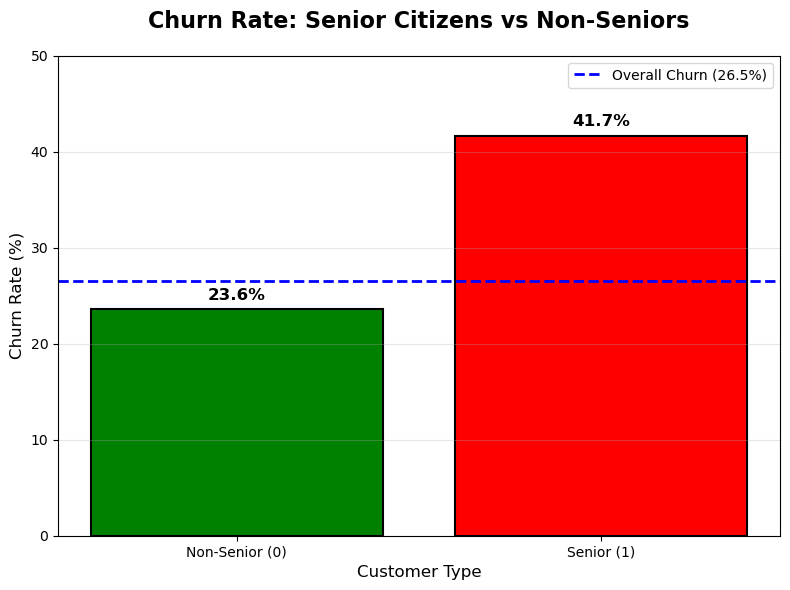

✅ Saved: churn_by_senior.png


<Figure size 640x480 with 0 Axes>

In [9]:
# Calculate data
senior_churn = churn_df.groupby('SeniorCitizen')['churn_binary'].mean() * 100

# Create figure
plt.figure(figsize=(8, 6))
colors = ['green', 'red']
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'], senior_churn.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize
plt.title('Churn Rate: Senior Citizens vs Non-Seniors', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Customer Type', fontsize=12)
plt.ylim(0, 50)
plt.axhline(y=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='upper right')

# Add value labels
for bar, val in zip(bars, senior_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Save
plt.savefig('churn_by_senior.png', dpi=300, bbox_inches='tight')
print("Saved: churn_by_senior.png")

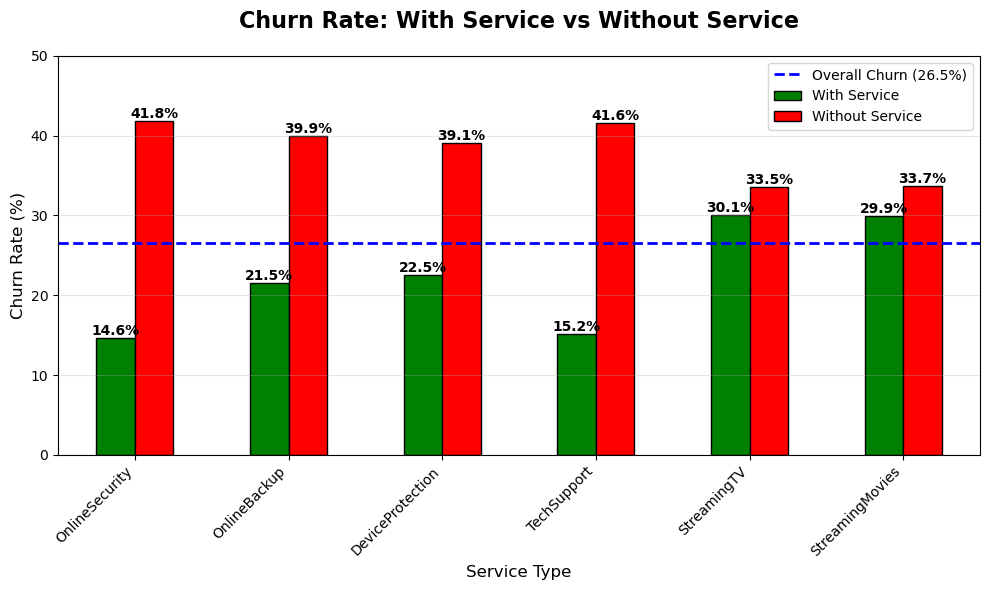

✅ Saved: service_impact_heatmap.png


<Figure size 640x480 with 0 Axes>

In [10]:
# Create service impact analysis
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_impact = {}

for service in services:
    with_service = churn_df[churn_df[service] == 'Yes']['churn_binary'].mean() * 100
    without_service = churn_df[churn_df[service] == 'No']['churn_binary'].mean() * 100
    service_impact[service] = {'With Service': with_service, 'Without Service': without_service}

impact_df = pd.DataFrame(service_impact).T

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
impact_df.plot(kind='bar', ax=ax, color=['green', 'red'], edgecolor='black', linewidth=1)

plt.title('Churn Rate: With Service vs Without Service', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Service Type', fontsize=12)
plt.ylim(0, 50)
plt.axhline(y=26.5, color='blue', linestyle='--', linewidth=2, label=f'Overall Churn (26.5%)')
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save
plt.savefig('service_impact_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: service_impact_heatmap.png")